# Part 1 — Sleep Spindle Detection

**Dataset**: ANPHY-Sleep (Participants 11–15)  

**Goal**: Detect sleep spindles (11–16 Hz oscillations, ~0.5–2 s) using a manual Hilbert-envelope method based on the Tsanas paper, benchmark against YASA, and compare detection sensitivity.  

**Reference**: Tsanas et al. — *Stage-independent, single lead EEG sleep spindle detection using the continuous wavelet transform and local weighted smoothing*

## 1. Setup & Imports

In [1]:
# Libraries
import mne
import yasa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from pathlib import Path
import warnings

# Configuration
mne.set_log_level("WARNING")
warnings.filterwarnings("ignore")

# Paths
DATA_DIR    = Path("../data/raw")
RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")
MANUAL_DIR  = Path("../data/processed/manual_detection")
YASA_DIR = Path("../data/processed/yasa_detection")
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
MANUAL_DIR.mkdir(parents=True, exist_ok=True)
YASA_DIR.mkdir(parents=True, exist_ok=True)

# Participants
PARTICIPANTS = [11, 12, 13, 14, 15]

/Users/neehanth/Documents/AI R&D Intern/assignments/EEG_Signal_Processing_Classification/eeg_signal_processing_classification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Acquisition & Inspection
**Assignment Task 1**: Retrieve `.edf` files for Participants 11–15 from the ANPHY-Sleep repository. Verify:
- Channel names and count
- Sampling frequency
- Recording duration
- Availability of central leads (C3, Cz, C4)

In [2]:
# Load each participant and collect metadata
CENTRAL_LEADS = {"C3", "CZ", "C4"}

inspection_rows = []

for pid in PARTICIPANTS:
    edf_path = DATA_DIR / f"EPCTL{pid}" / f"EPCTL{pid}.edf"
    
    raw = mne.io.read_raw_edf(edf_path, preload=False)
    
    # Find which central leads exist (exact match, case-insensitive)
    # available = [ch for ch in raw.ch_names if ch.upper() in CENTRAL_LEADS]
    central = [ch for ch in raw.ch_names if ch.upper().startswith("C")]
    
    duration_hrs = raw.times[-1] / 3600
    
    inspection_rows.append({
        "participant":           f"EPCTL{pid}",
        "n_channels":            len(raw.ch_names),
        "sfreq":                 raw.info["sfreq"],
        "duration_hrs":          round(duration_hrs, 2),
        "available_central":     ", ".join(central) if central else "NONE",
        "chosen_lead":           "",
        "notes":                 ""
    })
    
    print(f"--- EPCTL{pid} ---")
    print(f"   Channels : {len(raw.ch_names)}")
    print(f"   Sfreq    : {raw.info['sfreq']} Hz")
    print(f"   Duration : {duration_hrs:.2f} hrs")
    print(f"   Central  : {central}")
    print()

# Build inspection table
inspection_df = pd.DataFrame(inspection_rows)
inspection_df

--- EPCTL11 ---
   Channels : 93
   Sfreq    : 1000.0 Hz
   Duration : 6.60 hrs
   Central  : ['C3', 'C4', 'CZ', 'C5', 'C1', 'CP3', 'CP1', 'C6', 'C2', 'CPZ', 'CP2', 'CP4', 'CP6', 'ChEMG1', 'ChEMG2', 'CP5']

--- EPCTL12 ---
   Channels : 93
   Sfreq    : 1000.0 Hz
   Duration : 6.52 hrs
   Central  : ['C3', 'C4', 'CZ', 'C5', 'C1', 'CP3', 'CP1', 'C6', 'C2', 'CPZ', 'CP2', 'CP4', 'CP6', 'ChEMG1', 'ChEMG2', 'CP5']

--- EPCTL13 ---
   Channels : 93
   Sfreq    : 1000.0 Hz
   Duration : 7.71 hrs
   Central  : ['C3', 'C4', 'CZ', 'C5', 'C1', 'CP3', 'CP1', 'C6', 'C2', 'CPZ', 'CP2', 'CP4', 'CP6', 'ChEMG1', 'ChEMG2', 'CP5']

--- EPCTL14 ---
   Channels : 93
   Sfreq    : 1000.0 Hz
   Duration : 6.45 hrs
   Central  : ['C3', 'C4', 'CZ', 'C5', 'C1', 'CP3', 'CP1', 'C6', 'C2', 'CPZ', 'CP2', 'CP4', 'CP6', 'ChEMG1', 'ChEMG2', 'CP5']

--- EPCTL15 ---
   Channels : 93
   Sfreq    : 1000.0 Hz
   Duration : 6.29 hrs
   Central  : ['C3', 'C4', 'CZ', 'C5', 'C1', 'CP3', 'CP1', 'C6', 'C2', 'CPZ', 'CP2', 'CP4', 

,participant,n_channels,sfreq,duration_hrs,available_central,chosen_lead,notes
0,EPCTL11,93,1000.0,6.60,"C3, C4, CZ, C5, C1, CP3, CP1, C6, C2, CPZ, CP2...",,
1,EPCTL12,93,1000.0,6.52,"C3, C4, CZ, C5, C1, CP3, CP1, C6, C2, CPZ, CP2...",,
2,EPCTL13,93,1000.0,7.71,"C3, C4, CZ, C5, C1, CP3, CP1, C6, C2, CPZ, CP2...",,
3,EPCTL14,93,1000.0,6.45,"C3, C4, CZ, C5, C1, CP3, CP1, C6, C2, CPZ, CP2...",,
4,EPCTL15,93,1000.0,6.29,"C3, C4, CZ, C5, C1, CP3, CP1, C6, C2, CPZ, CP2...",,


## 3. Pre-processing

### 3a. Hypnogram Parsing
*Implementation choice*: Parse `.txt` sleep annotations to restrict analysis to N2 sleep, which is required for correct spindle density calculation.

In [3]:
def load_hypnogram(file_path):
    """
    Parses ANPHY-Sleep .txt annotation files into a formatted DataFrame.
    Format: Stage [tab] Start_Second [tab] Duration_Second
    """
    # Load with specific settings for this dataset's format
    df = pd.read_csv(
        file_path, 
        sep='\t', 
        header=None, 
        names=['stage', 'start_sec', 'duration_sec']
    )
    
    # Add an end_sec column for easier slicing logic later
    df['end_sec'] = df['start_sec'] + df['duration_sec']
    
    return df

In [4]:
# Example for EPCTL11
hypno_11 = load_hypnogram(DATA_DIR / "EPCTL11/EPCTL11.txt")

# Filter for N2 sleep
n2_epochs_11 = hypno_11[hypno_11['stage'] == 'N2']
n2_epochs_11

,stage,start_sec,duration_sec,end_sec
34,N2,1020,30,1050
35,N2,1050,30,1080
36,N2,1080,30,1110
37,N2,1110,30,1140
38,N2,1140,30,1170
...,...,...,...,...
741,N2,22230,30,22260
742,N2,22260,30,22290
743,N2,22290,30,22320
744,N2,22320,30,22350


In [5]:
# Store inspection timestamps for all participants
inspection_windows = {}

for pid in PARTICIPANTS:
    txt_path = DATA_DIR / f"EPCTL{pid}" / f"EPCTL{pid}.txt"
    hypno = load_hypnogram(txt_path)
    
    # Isolate N2 epochs
    n2_epochs = hypno[hypno['stage'] == 'N2'].reset_index(drop=True)
    n_total = len(n2_epochs)
    
    # Select roughly the 10%, 50%, and 90% points through the night's N2 sleep
    # We take the start_sec for a 30-second window
    idx_early  = int(n_total * 0.1)
    idx_middle = int(n_total * 0.5)
    idx_late   = int(n_total * 0.9)
    
    inspection_windows[pid] = {
        'early': n2_epochs.iloc[idx_early]['start_sec'],
        'middle': n2_epochs.iloc[idx_middle]['start_sec'],
        'late': n2_epochs.iloc[idx_late]['start_sec']
    }

pd.DataFrame(inspection_windows).T.rename_axis('Participant')

,early,middle,late
Participant,,,
11,5760,16260,21480
12,7680,15630,21330
13,5190,14790,23280
14,4950,10620,19350
15,6870,14370,20400


`Insights`:
- By isolating `N2` epochs up front, we can guarantee that the detector only targets relevant physiological windows, minimizing false positives during wake or REM stages.
- Rather than loading all 90+ channels for 6–8 hours of recording (~2.5GB per participant) into RAM, isolated three precise 30-second timestamps per participant.
- By sampling the 10th, 50th, and 90th percentiles of total N2 sleep, we can ensure the visual inspection captures signal quality across the early, middle, and late night, preventing bias from transient artifacts in any single phase of sleep.

### 3b. Broad Bandpass Filter
Apply a bandpass filter from 0.5–30 Hz to remove slow drifts and high-frequency muscle noise.

In [6]:
target_channels = ['C3', 'CZ', 'C4']

# Visualize one participant data (EPCTL11) for lead selection
pid = 11
edf_path = DATA_DIR / f"EPCTL{pid}" / f"EPCTL{pid}.edf"

# Load header and ONLY the 3 central channels
raw_central = mne.io.read_raw_edf(edf_path, include=target_channels, preload=False)

filtered_snippets = {}
windows_sec = inspection_windows[pid]

for label, start_sec in windows_sec.items():
    # Crop to the exact 30-second window
    # .copy() detaches the snippet so we can load it into memory
    raw_crop = raw_central.copy().crop(tmin=start_sec, tmax=start_sec + 30)
    
    # Load just these 30 seconds into RAM
    raw_crop.load_data()
    
    # Apply the Broad Filter (0.5 - 30 Hz)
    raw_crop.filter(l_freq=0.5, h_freq=30.0, fir_design='firwin', verbose=False)
    
    filtered_snippets[label] = raw_crop

print(f"Successfully loaded and filtered 3 representative windows for EPCTL{pid}.")

Successfully loaded and filtered 3 representative windows for EPCTL11.


### 3c. Lead Selection
Select a single EEG channel.

Sleep spindles are typically most prominent in the central region, especially around `C3`, `Cz`, and `C4`.

Although the ANPHY-Sleep recordings include several nearby central electrodes, the candidate set was restricted to the canonical central derivations `C3`, `CZ`, and `C4`, since these are the most standard leads for spindle inspection.

In [7]:
def plot_candidate_leads(pid, windows_dict, data_dir, target_channels=['C3', 'CZ', 'C4']):
    """
    Loads, filters, and plots candidate central channels for a specific participant
    across early, middle, and late N2 windows.
    """
    edf_path = data_dir / f"EPCTL{pid}" / f"EPCTL{pid}.edf"
    raw_central = mne.io.read_raw_edf(edf_path, include=target_channels, preload=False, verbose=False)
    
    # Extract and filter snippets
    filtered_snippets = {}
    windows_sec = windows_dict[pid]
    
    for label, start_sec in windows_sec.items():
        # Crop, load into RAM, and apply 0.5-30 Hz broad filter
        raw_crop = raw_central.copy().crop(tmin=start_sec, tmax=start_sec + 30)
        raw_crop.load_data(verbose=False)
        raw_crop.filter(l_freq=0.5, h_freq=30.0, fir_design='firwin', verbose=False)
        filtered_snippets[label] = raw_crop

    # Plotting
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))
    fig.suptitle(f"Candidate Central Leads: EPCTL{pid} (0.5-30Hz Filtered)", fontsize=16)
    colors = {'C3': '#1f77b4', 'CZ': '#2ca02c', 'C4': '#ff7f0e'}
    for ax, (label, snippet) in zip(axes, filtered_snippets.items()):
        times = snippet.times
        data = snippet.get_data() * 1e6  # Volts to μV
        
        offset = 0
        for idx, ch_name in enumerate(target_channels):
            ax.plot(times, data[idx] - offset, label=ch_name, color=colors[ch_name], linewidth=1)
            offset += 75  # Vertical spacing
            
        ax.set_title(f"{label.capitalize()} Night N2 Window (Start: {windows_sec[label]}s)")
        ax.set_ylabel("Amplitude (μV)")
        if label == 'early':
            ax.legend(loc='upper right', bbox_to_anchor=(1.08, 1))

    axes[-1].set_xlabel("Time within epoch (seconds)")
    plt.tight_layout()
    plt.show()

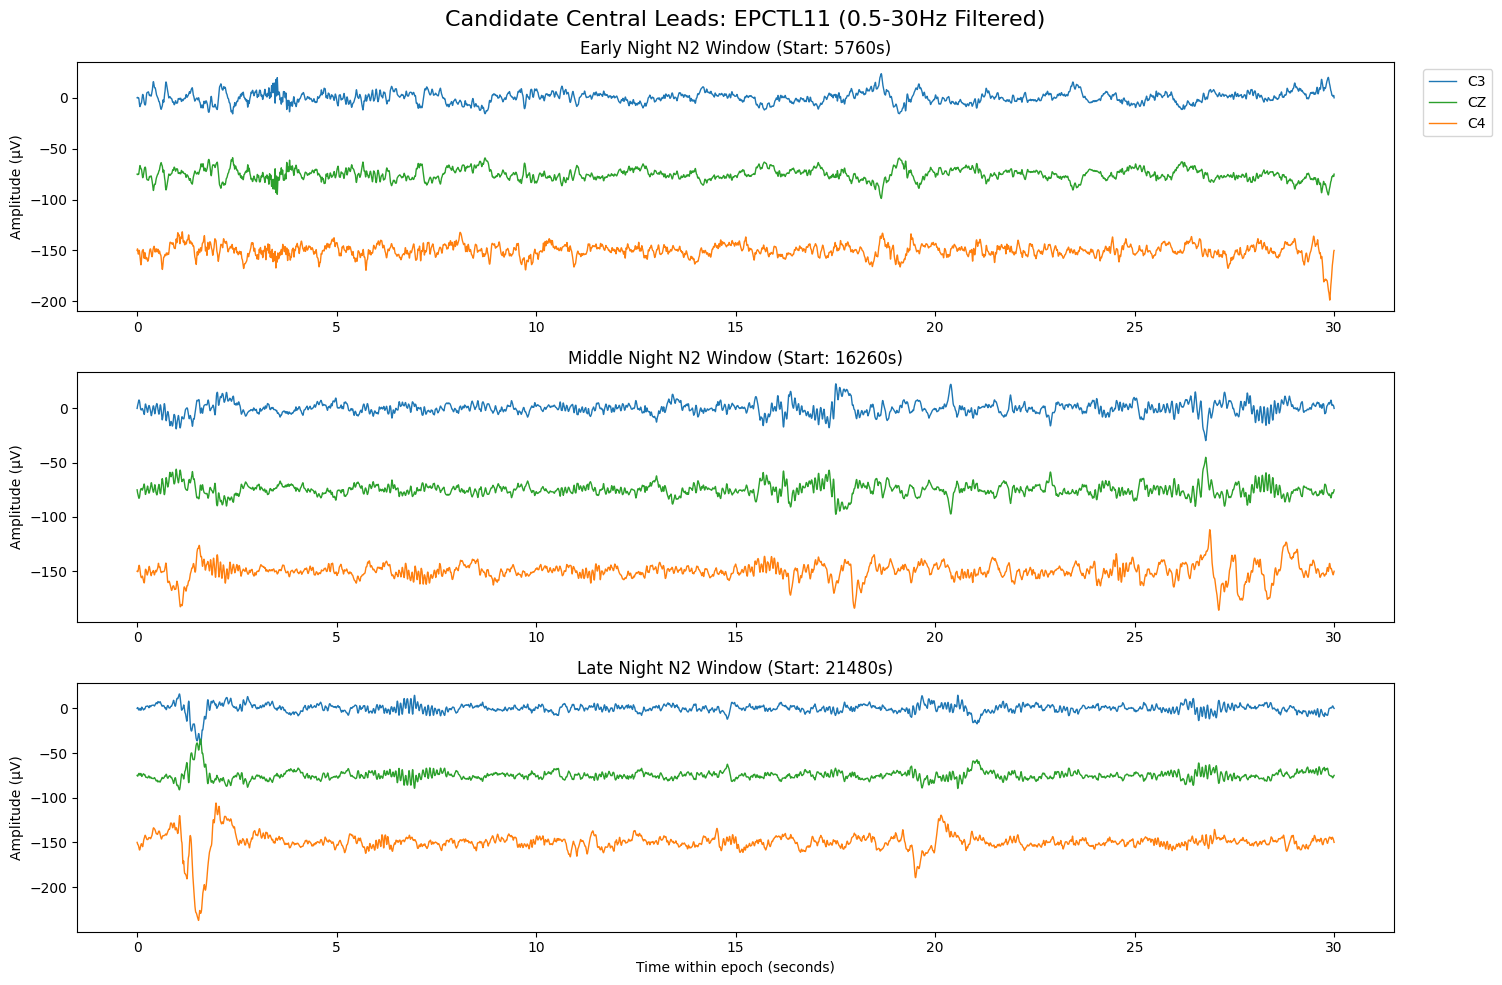

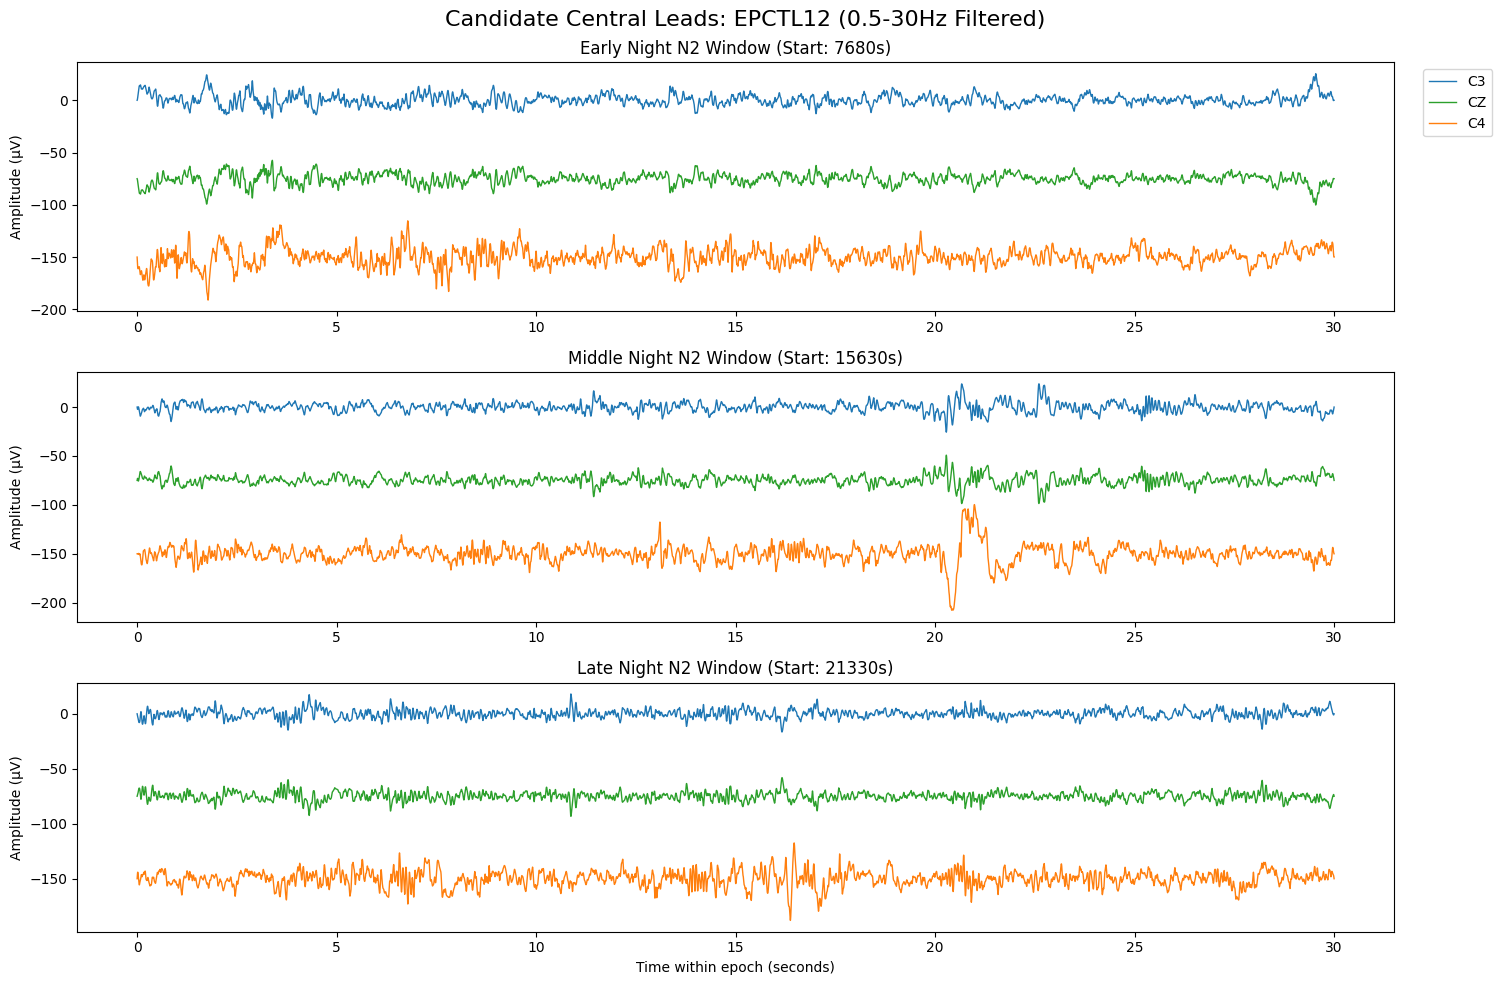

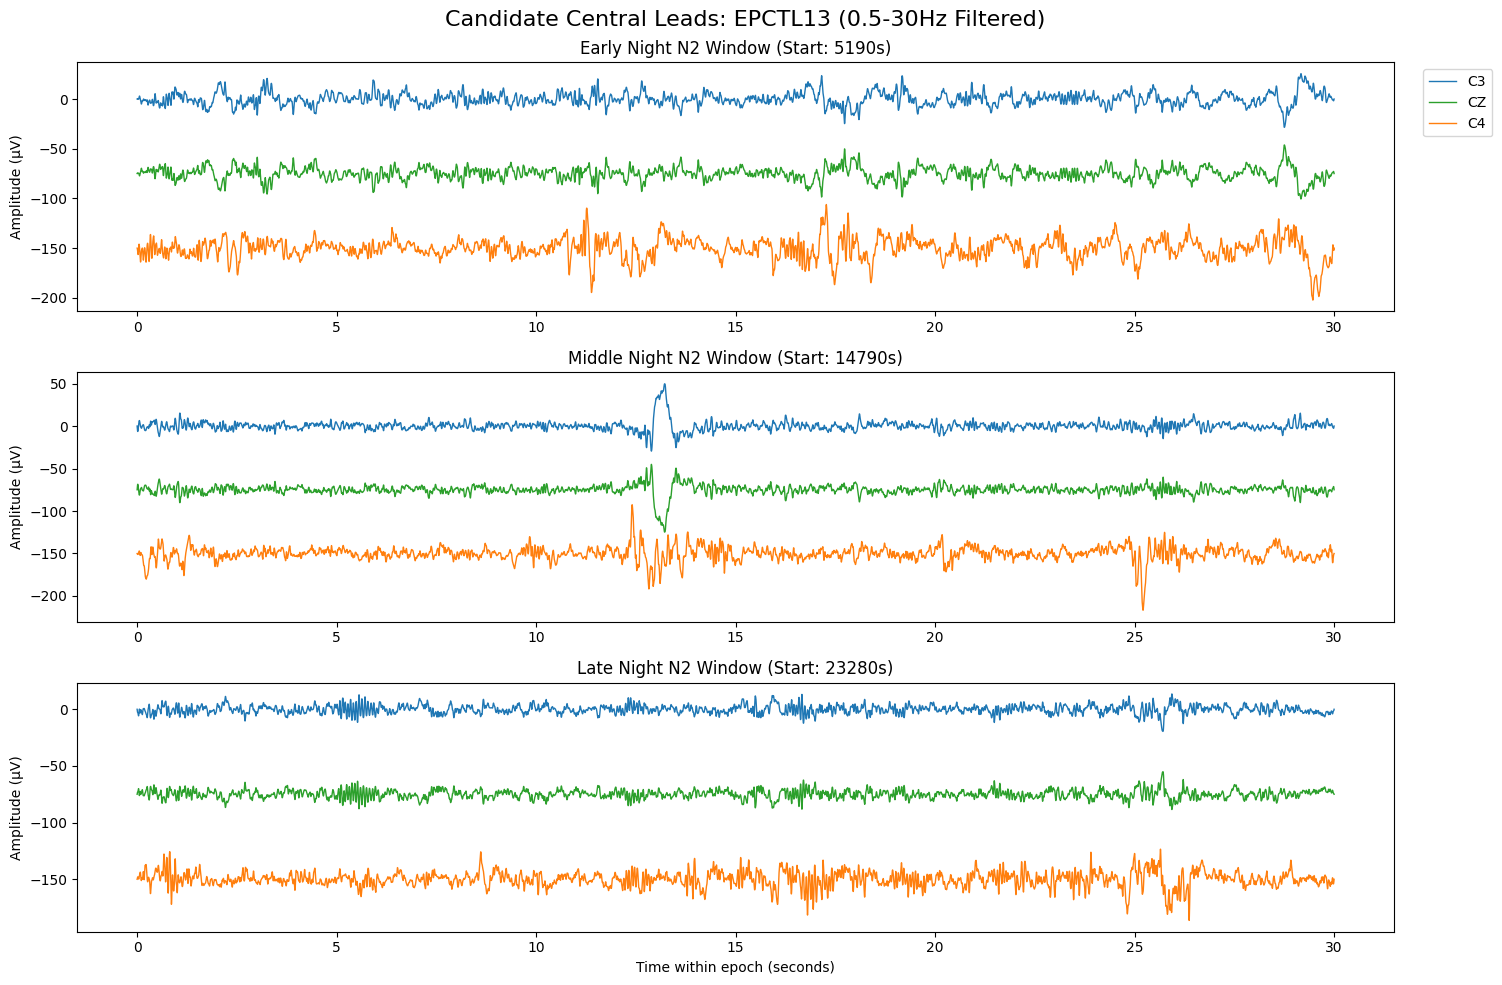

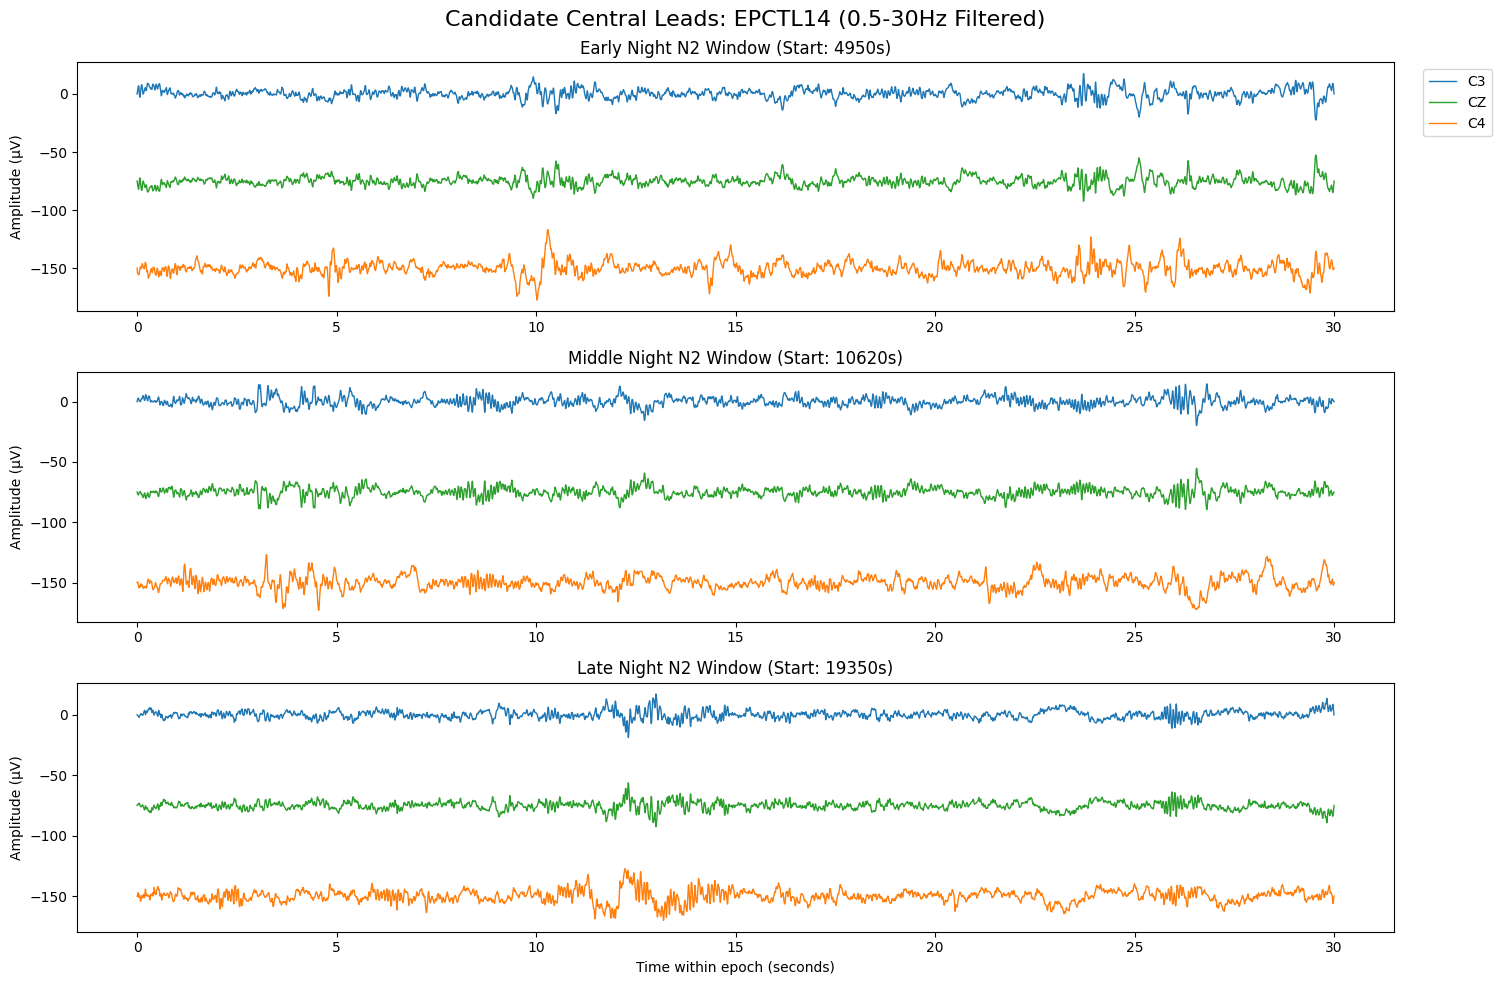

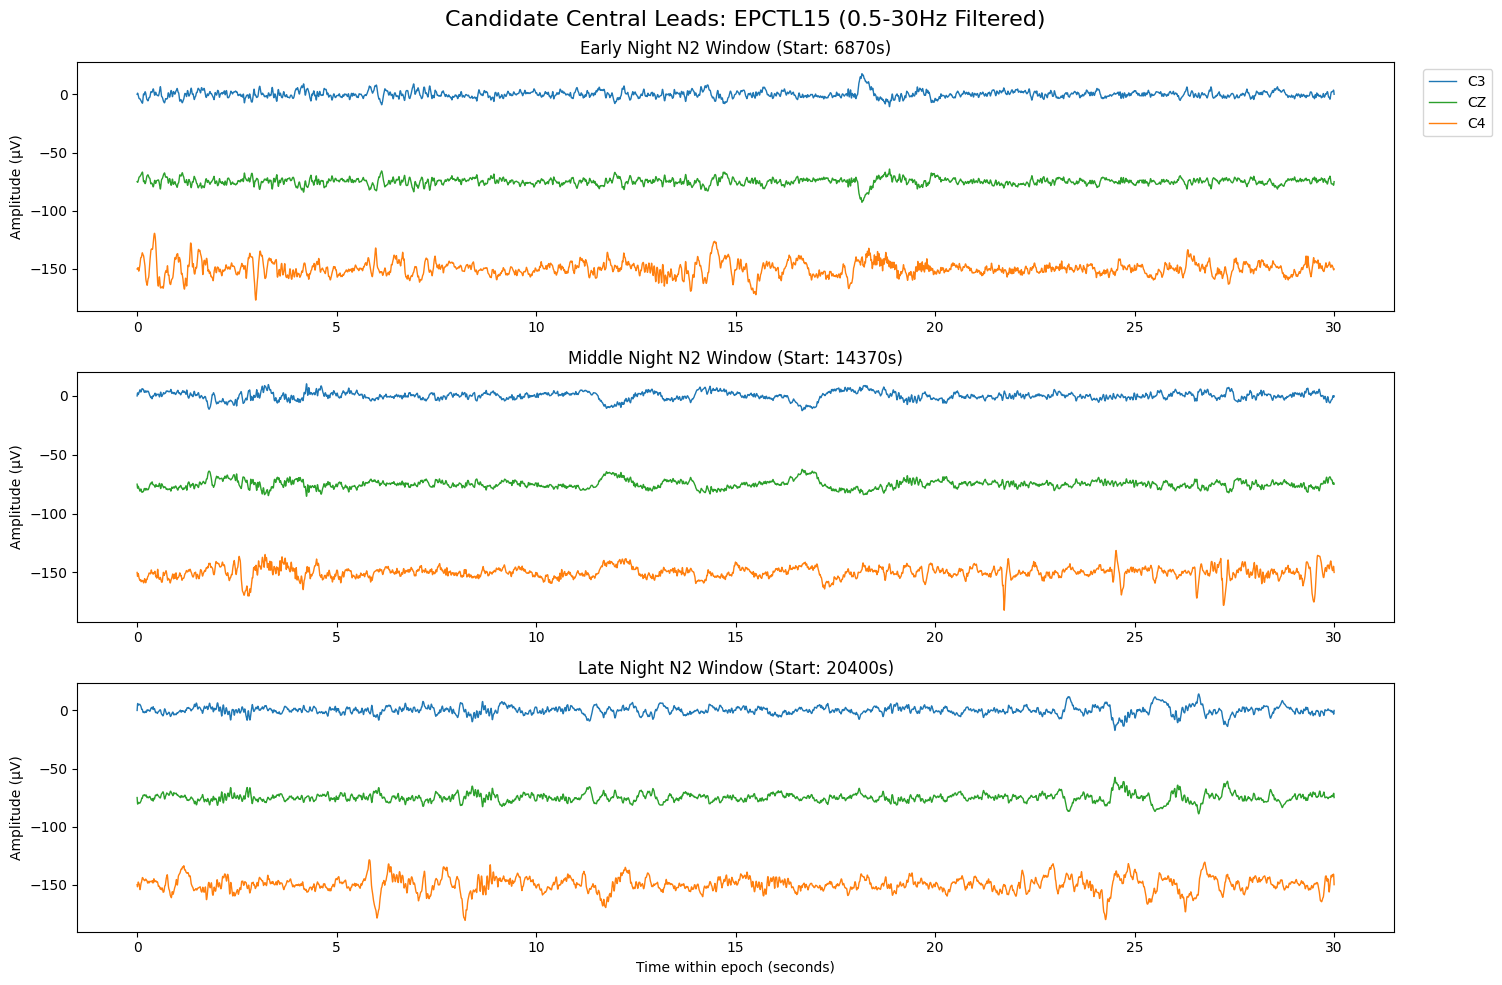

In [8]:
for pid in PARTICIPANTS:
    plot_candidate_leads(pid, inspection_windows, DATA_DIR)

In [9]:
# Updating the inspection data
inspection_df['chosen_lead'] = 'CZ'
inspection_df['selection_notes'] = 'C4 rejected (artifacts/baseline drift). C3 & CZ clean. CZ selected as midline standard.'

inspection_df

,participant,n_channels,sfreq,duration_hrs,available_central,chosen_lead,notes,selection_notes
0,EPCTL11,93,1000.0,6.60,"C3, C4, CZ, C5, C1, CP3, CP1, C6, C2, CPZ, CP2...",CZ,,C4 rejected (artifacts/baseline drift). C3 & C...
1,EPCTL12,93,1000.0,6.52,"C3, C4, CZ, C5, C1, CP3, CP1, C6, C2, CPZ, CP2...",CZ,,C4 rejected (artifacts/baseline drift). C3 & C...
2,EPCTL13,93,1000.0,7.71,"C3, C4, CZ, C5, C1, CP3, CP1, C6, C2, CPZ, CP2...",CZ,,C4 rejected (artifacts/baseline drift). C3 & C...
3,EPCTL14,93,1000.0,6.45,"C3, C4, CZ, C5, C1, CP3, CP1, C6, C2, CPZ, CP2...",CZ,,C4 rejected (artifacts/baseline drift). C3 & C...
4,EPCTL15,93,1000.0,6.29,"C3, C4, CZ, C5, C1, CP3, CP1, C6, C2, CPZ, CP2...",CZ,,C4 rejected (artifacts/baseline drift). C3 & C...


In [10]:
# Export the dataframe to csv
inspection_df.to_csv('../results/lead_selection_summary.csv', index=False)
print("Saved lead selection summary to results/lead_selection_summary.csv")

Saved lead selection summary to results/lead_selection_summary.csv


`Lead Selection Conclusion`:
- **Evaluated:** `C3`, `CZ`, `C4` across early, middle, and late *N2* sleep.
- **Rejected:** `C4` due to consistent baseline drift and severe, recurring high-amplitude noise artifacts observed across all 5 participants.
- **Selected:** `CZ`. Both `C3` and `CZ` demonstrated high signal integrity and stable baselines. `CZ` was chosen as the final analysis lead because it is the standard midline derivation in sleep medicine, maximizing spindle amplitude while preventing bias.

## 4. Custom Spindle Detection (Manual Method)
**Assignment Task 3**: Implement the core detection logic from the Tsanas paper.
- **Analytic Signal**: Bandpass to spindle range (11–16 Hz), compute Hilbert transform → amplitude envelope
- **Thresholding**: $$\text{threshold} = \text{mean} + k \times \text{std}$$ (k typically 1.5–4.5, optimized per subject)
- **Duration Constraints**: Keep only events lasting 0.5–2.0 s

In [11]:
from mne.filter import filter_data
from scipy.signal import hilbert

def moving_average(x, win_samples):
    """Simple centered moving average for envelope smoothing."""
    if win_samples <= 1:
        return x.copy()

    kernel = np.ones(win_samples, dtype=float) / win_samples
    return np.convolve(x, kernel, mode="same")

def build_stage_mask(hypno_df, n_samples, sfreq, target_stage="N2"):
    """Create a boolean sample mask for the requested sleep stage."""
    mask = np.zeros(n_samples, dtype=bool)

    stage_rows = hypno_df[hypno_df["stage"] == target_stage]
    for _, row in stage_rows.iterrows():
        start_idx = int(np.floor(row["start_sec"] * sfreq))
        end_idx   = int(np.floor(row["end_sec"] * sfreq))
        start_idx = max(0, start_idx)
        end_idx   = min(n_samples, end_idx)
        mask[start_idx:end_idx] = True

    return mask

def extract_segments(binary_mask):
    """Return [(start_idx, end_idx), ...] from a boolean mask."""
    edges = np.diff(binary_mask.astype(int), prepend=0, append=0)
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0]
    return list(zip(starts, ends))

In [12]:
def manual_spindle_detector(
    pid,
    data_dir,
    lead="CZ",
    broad_band=(0.5, 30.0),
    spindle_band=(11.0, 16.0),
    k=1.5,
    smooth_ms=200,
    min_duration=0.5,
    max_duration=2.0,
    target_stage="N2"
):
    edf_path = data_dir / f"EPCTL{pid}" / f"EPCTL{pid}.edf"
    txt_path = data_dir / f"EPCTL{pid}" / f"EPCTL{pid}.txt"

    # Load the EEG data and apply broad filter (0.5 - 30 Hz)
    raw = mne.io.read_raw_edf(edf_path, include=[lead], preload=True, verbose=False)
    raw.filter(l_freq=broad_band[0], h_freq=broad_band[1], fir_design="firwin", verbose=False)

    sfreq = raw.info["sfreq"]
    raw_signal = raw.get_data()[0]  # volts
    n_samples = raw_signal.size
    times = np.arange(n_samples) / sfreq

    # Isolate the spindle band (11–16 Hz)
    spindle_signal = filter_data(
        raw_signal,
        sfreq=sfreq,
        l_freq=spindle_band[0],
        h_freq=spindle_band[1],
        fir_design="firwin",
        verbose=False,
    )

    # Hilbert transform → envelope
    envelope = np.abs(hilbert(spindle_signal))

    # Smooth the envelope using simple moving average
    # to reduce small fluctuations → noise does not trigger false detections
    smooth_samples = max(1, int(round((smooth_ms / 1000) * sfreq)))
    envelope_smooth = moving_average(envelope, smooth_samples)

    # Focus only on N2 sleep stage
    hypno = load_hypnogram(txt_path)
    stage_mask = build_stage_mask(hypno, n_samples=n_samples, sfreq=sfreq, target_stage=target_stage)

    # Threshold is estimated only from the target stage (N2)
    stage_envelope = envelope_smooth[stage_mask]
    if len(stage_envelope) == 0:
        raise ValueError(f"No {target_stage} samples found for EPCTL{pid}")
    threshold = stage_envelope.mean() + k * stage_envelope.std()

    # Find candidate events (envolpe above threshold → Spindle)
    above_thr = (envelope_smooth > threshold) & stage_mask
    segments = extract_segments(above_thr)
    
    # Keep only realistic spindle durations (events lasting 0.5 to 2.0s)
    events = []
    for start_idx, end_idx in segments:
        duration = (end_idx - start_idx) / sfreq
        if min_duration <= duration <= max_duration:
            peak_rel = np.argmax(envelope_smooth[start_idx:end_idx])
            peak_idx = start_idx + peak_rel

            # Save spindle information
            events.append({
                "participant": f"EPCTL{pid}",
                "lead": lead,
                "start_idx": start_idx,
                "end_idx": end_idx,
                "start_sec": start_idx / sfreq,
                "end_sec": end_idx / sfreq,
                "duration_sec": duration,
                "peak_sec": peak_idx / sfreq,
                "peak_amp_uv": envelope_smooth[peak_idx] * 1e6,
            })

    events_df = pd.DataFrame(events)

    # Compute summary metrics
    total_stage_min = stage_mask.sum() / sfreq / 60.0
    spindle_count = len(events_df)
    density = spindle_count / total_stage_min if total_stage_min > 0 else np.nan
    avg_duration = events_df["duration_sec"].mean() if spindle_count else np.nan

    summary = {
        "participant": f"EPCTL{pid}",
        "lead": lead,
        "stage_used": target_stage,
        "k": k,
        "smooth_ms": smooth_ms,
        "threshold_uv": threshold * 1e6,
        "n_spindles": spindle_count,
        "stage_minutes": total_stage_min,
        "spindle_density_per_min": density,
        "avg_duration_sec": avg_duration,
    }

    output = {
        "events": events_df,
        "summary": summary,
        "raw": raw,
        "sfreq": sfreq,
        "times": times,
        "raw_signal": raw_signal,
        "spindle_signal": spindle_signal,
        "envelope": envelope,
        "envelope_smooth": envelope_smooth,
        "threshold": threshold,
        "stage_mask": stage_mask,
    }

    return output

In [49]:
# Test for one participant
pid_to_test = 11
k_values = [1.2, 1.5, 1.8]
smooth_values = [100, 200, 300]
grid_results = []

print(f"Running Grid Search for Participant {pid_to_test}...")
for k in k_values:
    for smooth_ms in smooth_values:
        print(f"   → k={k} | smooth_ms={smooth_ms}")
        manual_test = manual_spindle_detector(
            pid=pid_to_test,
            data_dir=DATA_DIR,
            lead="CZ",
            k=k,
            smooth_ms=smooth_ms,
            min_duration=0.5,
            max_duration=2.0
        )
        grid_results.append(manual_test["summary"])

grid_df = pd.DataFrame(grid_results)
grid_df.to_csv("../results/hyperparameter_grid_search_EPCTL11.csv", index=False)
grid_df

Running Grid Search for Participant 11...
   → k=1.2 | smooth_ms=100
   → k=1.2 | smooth_ms=200
   → k=1.2 | smooth_ms=300
   → k=1.5 | smooth_ms=100
   → k=1.5 | smooth_ms=200
   → k=1.5 | smooth_ms=300
   → k=1.8 | smooth_ms=100
   → k=1.8 | smooth_ms=200
   → k=1.8 | smooth_ms=300


,participant,lead,stage_used,k,smooth_ms,threshold_uv,n_spindles,stage_minutes,spindle_density_per_min,avg_duration_sec
0,EPCTL11,CZ,N2,1.2,100,3.401660,484,149.0,3.248322,0.772583
1,EPCTL11,CZ,N2,1.2,200,3.311007,619,149.0,4.154362,0.804559
2,EPCTL11,CZ,N2,1.2,300,3.240291,726,149.0,4.872483,0.838781
3,EPCTL11,CZ,N2,1.5,100,3.802233,368,149.0,2.469799,0.742913
4,EPCTL11,CZ,N2,1.5,200,3.688917,447,149.0,3.000000,0.779647
5,EPCTL11,CZ,N2,1.5,300,3.600522,537,149.0,3.604027,0.808343
6,EPCTL11,CZ,N2,1.8,100,4.202806,269,149.0,1.805369,0.710175
7,EPCTL11,CZ,N2,1.8,200,4.066827,340,149.0,2.281879,0.743085
8,EPCTL11,CZ,N2,1.8,300,3.960752,405,149.0,2.718121,0.768575


**Parameter justification:**

- At `k = 1.2`, counts rise quickly as smoothing increases: `484` → `619` → `726`
- At `k = 1.5`, the counts are more moderate: `368` → `447` → `537`
- At `k = 1.8`, the detector is too strict for this participant: `269` → `340` → `405`

Since `YASA = 468`, the closest manual result is:
- `k = 1.2`, `smooth_ms = 100` → 484 spindles
    - Difference = `+16`
    - Percent difference = `+3.42%`

In [51]:
from mne.time_frequency import psd_array_welch

def plot_manual_diagnostic_with_psd(
    result,
    start_sec,
    duration_sec=30,
    spindle_number_in_window=0,
    pad_sec=1.0,
    save_path=None
):
    """
    Plot:
    1) Raw EEG with manual detections
    2) Spindle-band signal
    3) Smoothed Hilbert envelope + threshold
    4) PSD around one detected spindle using MNE psd_array_welch
    """
    sfreq = result["sfreq"]
    start_idx = int(start_sec * sfreq)
    end_idx = int((start_sec + duration_sec) * sfreq)

    t = result["times"][start_idx:end_idx]
    raw_uv = result["raw_signal"][start_idx:end_idx] * 1e6
    spindle_uv = result["spindle_signal"][start_idx:end_idx] * 1e6
    env_uv = result["envelope_smooth"][start_idx:end_idx] * 1e6
    thr_uv = result["threshold"] * 1e6

    events = result["events"]
    events_win = events[
        (events["end_sec"] >= start_sec) &
        (events["start_sec"] <= start_sec + duration_sec)
    ].reset_index(drop=True)

    n_psd = max(1, len(events_win))
    nrows = 3 + n_psd

    fig, axes = plt.subplots(nrows, 1, figsize=(15, 3 * nrows), sharex=False, layout='constrained')

    # Raw EEG
    axes[0].plot(t, raw_uv, linewidth=0.8)
    for _, row in events_win.iterrows():
        axes[0].axvspan(row["start_sec"], row["end_sec"], color="limegreen", alpha=0.25)
    axes[0].set_title("Raw EEG (0.5-30 Hz) with manual detections")
    axes[0].set_ylabel("μV")

    # Spindle-band signal
    axes[1].plot(t, spindle_uv, linewidth=0.8, color="purple")
    for _, row in events_win.iterrows():
        axes[1].axvspan(row["start_sec"], row["end_sec"], color="limegreen", alpha=0.20)
    axes[1].set_title("Spindle-band signal (11-16 Hz)")
    axes[1].set_ylabel("μV")

    # Envelope + threshold
    axes[2].plot(t, env_uv, linewidth=1.0, color="black", label="Smoothed envelope")
    axes[2].axhline(thr_uv, color="red", linestyle="--", label=f"Threshold = {thr_uv:.2f} μV")
    for _, row in events_win.iterrows():
        axes[2].axvspan(row["start_sec"], row["end_sec"], color="limegreen", alpha=0.20)
    axes[2].set_title("Hilbert envelope with threshold")
    axes[2].set_ylabel("μV")
    axes[2].set_xlabel("Time (s)")
    axes[2].legend(loc="upper right")

    # PSD around the detected spindles
    if len(events_win) == 0:
        axes[3].text(
            0.5, 0.5,
            "No detected spindle in this window for PSD",
            ha="center", va="center", fontsize=12
        )
        axes[3].set_title("PSD around detected spindle")
        axes[3].set_xticks([])
        axes[3].set_yticks([])
    else:
        for i, (_, event) in enumerate(events_win.iterrows()):
            ax = axes[3 + i]

            psd_start_sec = max(0, event["start_sec"] - pad_sec)
            psd_end_sec = event["end_sec"] + pad_sec

            psd_start_idx = int(psd_start_sec * sfreq)
            psd_end_idx = int(psd_end_sec * sfreq)

            segment_uv = result["raw_signal"][psd_start_idx:psd_end_idx] * 1e6

            n_per_seg = len(segment_uv)
            n_fft = max(256, n_per_seg)

            psd, freqs = psd_array_welch(
                segment_uv,
                sfreq=sfreq,
                fmin=0.5,
                fmax=30.0,
                n_fft=n_fft,
                n_per_seg=n_per_seg,
                n_overlap=n_per_seg // 2,
                average="mean",
                remove_dc=True,
                verbose=False,
            )

            spindle_mask = (freqs >= 11) & (freqs <= 16)
            if spindle_mask.sum() > 0:
                spindle_freqs = freqs[spindle_mask]
                spindle_psd = psd[spindle_mask]
                peak_idx = np.argmax(spindle_psd)
                peak_freq = spindle_freqs[peak_idx]
                peak_power = spindle_psd[peak_idx]
            else:
                peak_freq = None
                peak_power = None

            ax.plot(freqs, psd, linewidth=1.2)
            ax.axvspan(11, 16, color="orange", alpha=0.20, label="Spindle band (11-16 Hz)")

            if peak_freq is not None:
                ax.axvline(peak_freq, color="red", linestyle="--",
                           label=f"Peak = {peak_freq:.2f} Hz")
                ax.axhline(peak_power, color="green", linestyle="--",
                           label=f"Peak power = {peak_power:.2f}")
                ax.scatter([peak_freq], [peak_power], color="red", zorder=3)
            
            ax.set_ylim(0, 30)

            ax.set_title(
                f"PSD for spindle {i+1} ({event['start_sec']:.3f}-{event['end_sec']:.3f} s, "
                f"dur = {event['duration_sec']:.3f} s)"
            )
            ax.set_xlabel("Frequency (Hz)")
            ax.set_ylabel("PSD (μV²/Hz)")
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                ax.legend(handles, labels, loc="upper right", frameon=True)
    
    # Save the plot
    if save_path:
        plt.savefig(save_path, dpi=300, facecolor='white', transparent=False)
        print(f"Figure successfully saved to: {save_path}")

    plt.tight_layout(pad=3.0)
    plt.show()

Figure successfully saved to: ../figures/manual_spindle_detection_plot_EPCTL11.png


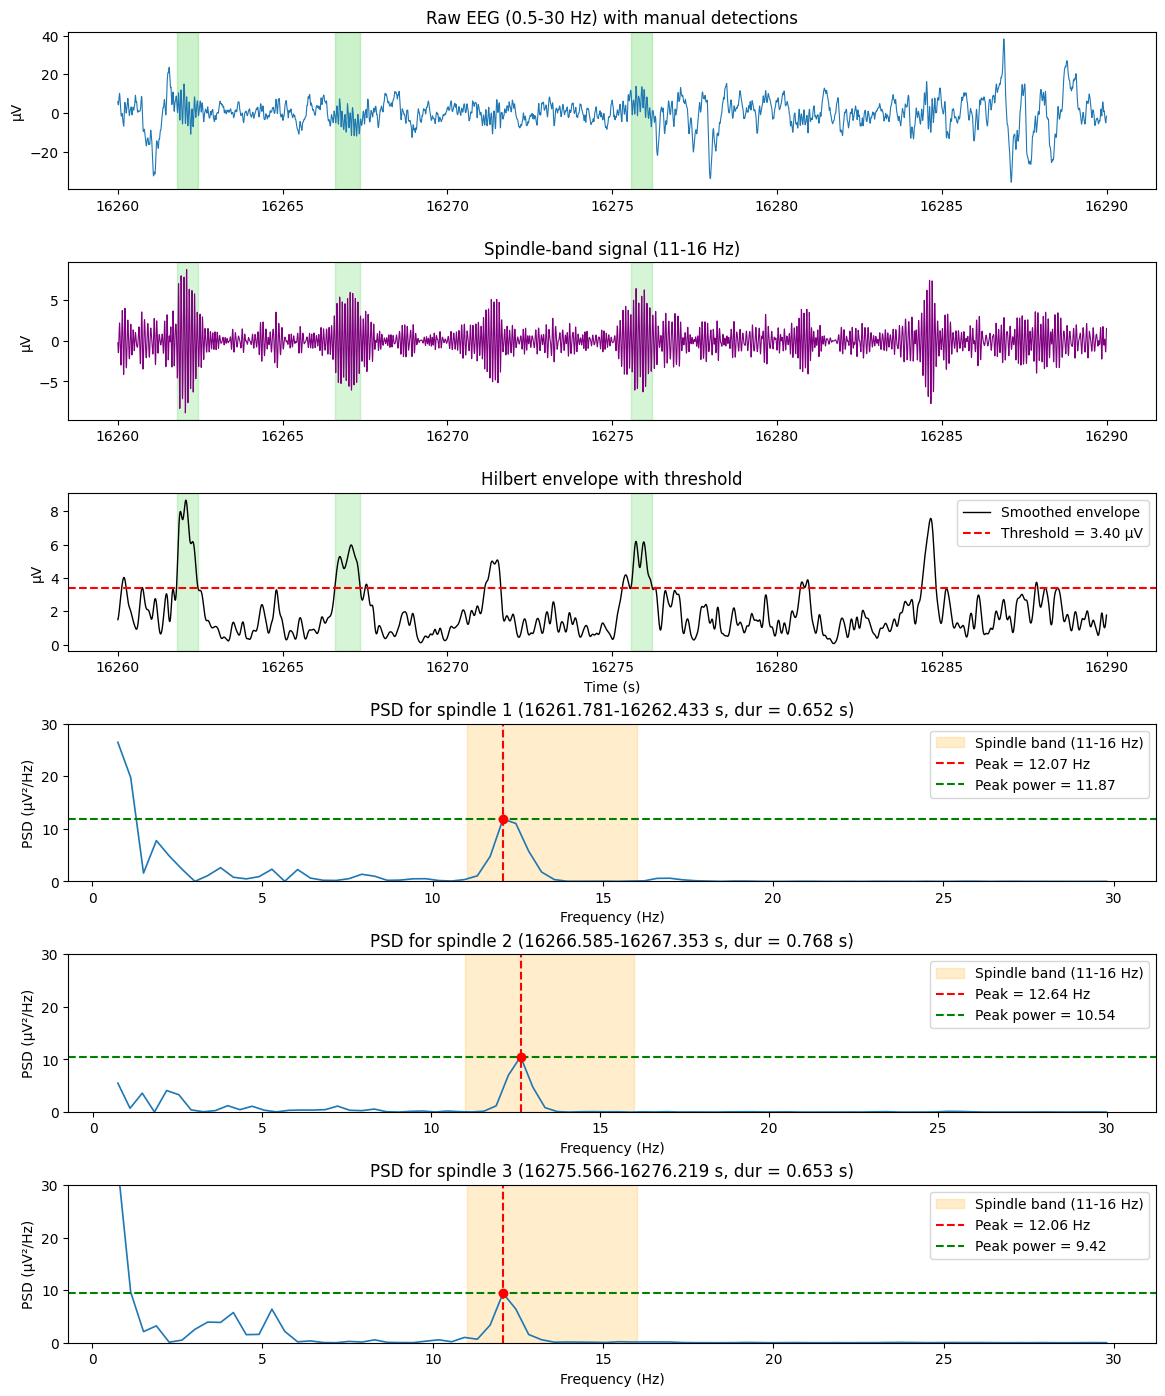

In [54]:
manual_test = manual_spindle_detector(
    pid=11,
    data_dir=DATA_DIR,
    lead="CZ",
    k=1.2,
    smooth_ms=100,
    min_duration=0.5,
    max_duration=2.0
)

plot_manual_diagnostic_with_psd(
    manual_test,
    start_sec=inspection_windows[11]["middle"],
    duration_sec=30,
    pad_sec=1.0,
    save_path=FIGURES_DIR / "manual_spindle_detection_plot_EPCTL11.png"
)

In [53]:
# Numerical inspection for detected spindles
sfreq = manual_test["sfreq"]
env = manual_test["envelope_smooth"]
thr = manual_test["threshold"]
stage_mask = manual_test["stage_mask"]

above_thr = (env > thr) & stage_mask
segments = extract_segments(above_thr)

window_start = inspection_windows[11]["middle"]
window_end = window_start + 30

rows = []
for start_idx, end_idx in segments:
    start_sec = start_idx / sfreq
    end_sec = end_idx / sfreq
    duration = end_sec - start_sec

    if end_sec >= window_start and start_sec <= window_end:
        rows.append({
            "start_sec": start_sec,
            "end_sec": end_sec,
            "duration_sec": duration,
            "kept_final": ((manual_test["events"]["start_sec"] == start_sec) &
                           (manual_test["events"]["end_sec"] == end_sec)).any()
        })

pd.DataFrame(rows)

,start_sec,end_sec,duration_sec,kept_final
0,16260.147,16260.224,0.077,False
1,16261.790,16262.405,0.615,True
2,16266.606,16267.333,0.727,True
3,16271.204,16271.608,0.404,False
4,16275.340,16275.484,0.144,False
5,16275.600,16276.175,0.575,True
6,16280.908,16280.952,0.044,False
7,16284.410,16284.816,0.406,False


In [55]:
# Run manual spindle detection on all participants and save outputs
MANUAL_PARAMS = {"lead": "CZ", "k": 1.2, "smooth_ms": 100}

manual_summary_rows = []
manual_events_all = []

for pid in PARTICIPANTS:
    print(f"Processing EPCTL{pid} | lead={MANUAL_PARAMS['lead']} | k={MANUAL_PARAMS['k']} | smooth_ms={MANUAL_PARAMS['smooth_ms']}")
    
    result = manual_spindle_detector(
        pid=pid,
        data_dir=DATA_DIR,
        lead=MANUAL_PARAMS["lead"],
        k=MANUAL_PARAMS["k"],
        smooth_ms=MANUAL_PARAMS["smooth_ms"],
        min_duration=0.5,
        max_duration=2.0
    )

    summary_row = result["summary"]
    events_df = result["events"].copy()

    # Add parameter columns to events too
    events_df["k"] = MANUAL_PARAMS["k"]
    events_df["smooth_ms"] = MANUAL_PARAMS["smooth_ms"]
    events_df["threshold_uv"] = summary_row["threshold_uv"]

    manual_summary_rows.append(summary_row)
    manual_events_all.append(events_df)

manual_summary_df = pd.DataFrame(manual_summary_rows)
manual_events_df = pd.concat(manual_events_all, ignore_index=True)

# Save combined outputs
manual_summary_df.to_csv(MANUAL_DIR / "manual_spindle_summary.csv", index=False)
manual_events_df.to_csv(MANUAL_DIR / "manual_spindle_events_all.csv", index=False)

manual_summary_df

Processing EPCTL11 | lead=CZ | k=1.2 | smooth_ms=100
Processing EPCTL12 | lead=CZ | k=1.2 | smooth_ms=100
Processing EPCTL13 | lead=CZ | k=1.2 | smooth_ms=100
Processing EPCTL14 | lead=CZ | k=1.2 | smooth_ms=100
Processing EPCTL15 | lead=CZ | k=1.2 | smooth_ms=100


,participant,lead,stage_used,k,smooth_ms,threshold_uv,n_spindles,stage_minutes,spindle_density_per_min,avg_duration_sec
0,EPCTL11,CZ,N2,1.2,100,3.401660,484,149.0,3.248322,0.772583
1,EPCTL12,CZ,N2,1.2,100,4.633931,218,127.0,1.716535,0.668757
2,EPCTL13,CZ,N2,1.2,100,5.462327,407,182.5,2.230137,0.689455
3,EPCTL14,CZ,N2,1.2,100,3.672626,474,148.5,3.191919,0.773492
4,EPCTL15,CZ,N2,1.2,100,2.350434,318,155.5,2.045016,0.720575


## 5. Automated Benchmark (YASA)
**Assignment Task 4**: Run YASA spindle detection on the same participants/channel. Document differences in detection sensitivity.

In [18]:
import yasa
import pandas as pd

yasa_summary_rows = []
yasa_events_all = []

for pid in PARTICIPANTS:
    print(f"Running YASA for EPCTL{pid}...")
    
    # Load the data (no need to pre-filter, YASA will do it internally based on freq_broad)
    edf_path = DATA_DIR / f"EPCTL{pid}" / f"EPCTL{pid}.edf"
    
    # preload=True → YASA needs the actual signal data
    raw = mne.io.read_raw_edf(edf_path, include=["CZ"], preload=True, verbose=False)
    
    # Create the N2 mask
    txt_path = DATA_DIR / f"EPCTL{pid}" / f"EPCTL{pid}.txt"
    hypno = load_hypnogram(txt_path)
    stage_mask = build_stage_mask(hypno, n_samples=raw.n_times, sfreq=raw.info['sfreq'], target_stage="N2")
    
    # Detect Spindles
    sp_yasa = yasa.spindles_detect(
        data=raw,                       # Pass MNE object directly; YASA auto-extracts CZ and converts to uV
        hypno=stage_mask.astype(int),   # Convert boolean array to 0s and 1s
        include=(1,),                   # Tell YASA to only search where hypno == 1 (N2)
        freq_sp=(11.0, 16.0),           # Align to the spindle block
        freq_broad=(0.5, 30.0),         # Align to the broad block
        duration=(0.5, 2.0),            # Align durations
        remove_outliers=False           # Keep it raw for 1:1 comparison
    )
    
    if sp_yasa is not None:
        # Extract the detailed dataframe
        events_df = sp_yasa.summary()
        events_df["participant"] = f"EPCTL{pid}"
        yasa_events_all.append(events_df)
        
        # Save a summary comparable to your manual summary
        yasa_summary_rows.append({
            "participant": f"EPCTL{pid}",
            "yasa_n_spindles": len(events_df),
            "yasa_avg_duration_sec": events_df["Duration"].mean(),
            "yasa_spindle_density_per_min": len(events_df) / (stage_mask.sum() / raw.info['sfreq'] / 60.0) 
        })
    else:
        print(f"No spindles detected by YASA for EPCTL{pid}")

yasa_summary_df = pd.DataFrame(yasa_summary_rows)
yasa_events_df = pd.concat(yasa_events_all, ignore_index=True)

Running YASA for EPCTL11...
Running YASA for EPCTL12...
Running YASA for EPCTL13...
Running YASA for EPCTL14...
Running YASA for EPCTL15...


In [19]:
yasa_summary_df

,participant,yasa_n_spindles,yasa_avg_duration_sec,yasa_spindle_density_per_min
0,EPCTL11,468,0.892615,3.140940
1,EPCTL12,177,0.774079,1.393701
2,EPCTL13,683,0.833445,3.742466
3,EPCTL14,485,0.927118,3.265993
4,EPCTL15,119,0.764975,0.765273


In [20]:
# Save the YASA results
yasa_summary_df.to_csv(YASA_DIR / "yasa_spindle_summary.csv", index=False)
yasa_events_df.to_csv(YASA_DIR / "yasa_spindle_events_all.csv", index=False)
print(f"Successfully saved YASA summary and events to {YASA_DIR}")

Successfully saved YASA summary and events to ../data/processed/yasa_detection


## 6. Performance Comparison Table
**Deliverable 1**: For each participant (11–15), compute:

| Metric | Manual | YASA | % Difference |
|---|---|---|---|
| Total Spindle Count | | | |
| Spindle Density (count/min) | | | |
| Avg. Duration (sec) | | | |

In [56]:
manual_sum = pd.read_csv("../data/processed/manual_detection/manual_spindle_summary.csv")
yasa_sum = pd.read_csv("../data/processed/yasa_detection/yasa_spindle_summary.csv")

comparison_df = pd.merge(
    manual_sum[['participant', 'n_spindles', 'spindle_density_per_min', 'avg_duration_sec']],
    yasa_sum[['participant', 'yasa_n_spindles', 'yasa_spindle_density_per_min', 'yasa_avg_duration_sec']],
    on='participant'
)

comparison_df["Density_%_Difference"] = (
    (comparison_df["spindle_density_per_min"] - comparison_df["yasa_spindle_density_per_min"])
    / comparison_df["yasa_spindle_density_per_min"]
) * 100

comparison_df["Duration_%_Difference"] = (
    (comparison_df["avg_duration_sec"] - comparison_df["yasa_avg_duration_sec"])
    / comparison_df["yasa_avg_duration_sec"]
) * 100

comparison_df = comparison_df.rename(columns={
    'n_spindles':                  'Manual_Count',
    'yasa_n_spindles':             'YASA_Count',
    'spindle_density_per_min':     'Manual_Density',
    'yasa_spindle_density_per_min':'YASA_Density',
    'avg_duration_sec':            'Manual_Avg_Duration',
    'yasa_avg_duration_sec':       'YASA_Avg_Duration'
})
comparison_df = comparison_df.round(2)

comparison_df.to_csv("../results/spindle_performance_comparison.csv", index=False)
comparison_df

,participant,Manual_Count,Manual_Density,Manual_Avg_Duration,YASA_Count,YASA_Density,YASA_Avg_Duration,Density_%_Difference,Duration_%_Difference
0,EPCTL11,484,3.25,0.77,468,3.14,0.89,3.42,-13.45
1,EPCTL12,218,1.72,0.67,177,1.39,0.77,23.16,-13.61
2,EPCTL13,407,2.23,0.69,683,3.74,0.83,-40.41,-17.28
3,EPCTL14,474,3.19,0.77,485,3.27,0.93,-2.27,-16.57
4,EPCTL15,318,2.05,0.72,119,0.77,0.76,167.23,-5.80


**Comparison insights:**

Using `k = 1.2` and `smooth_ms = 100` for all participants produced mixed agreement with YASA. The manual detector matched YASA relatively well for **EPCTL11** and **EPCTL14**, where the spindle counts and densities were very close. For **EPCTL12**, the manual method detected somewhat more spindles than YASA, showing a moderate increase in sensitivity.

The largest differences appeared for **EPCTL13** and **EPCTL15**. For **EPCTL13**, the manual detector found fewer spindles than YASA, suggesting that this setting may still be too conservative for that participant. In contrast, for **EPCTL15**, the manual detector found substantially more spindles than YASA, which suggests over-detection and stronger sensitivity to that participant’s signal characteristics.

A consistent pattern across all participants is that the **average spindle duration from the manual method is shorter than YASA**, which means the manual detector is often capturing narrower spindle segments. Overall, this parameter setting works well for some participants but does not generalize equally across all subjects, highlighting the effect of subject-to-subject EEG variability on spindle detection performance.

## 7. Visual Proof
**Deliverable 2**: For two example segments:
- **Overlay Plot**: Raw EEG with manual detections (green) and YASA detections (red) highlighted
- **PSD Plot**: Power Spectral Density showing the peak during a detected spindle

In [ ]:
from matplotlib.patches import Patch

VISUAL_PIDS = [11, 12]
VISUAL_DIR = FIGURES_DIR / "part1_visual_proof"
VISUAL_DIR.mkdir(parents=True, exist_ok=True)

def choose_visual_window(manual_events, yasa_events, fallback_start, duration_sec=30):
    """
    Try to choose a useful 30-second window:
    1) Prefer a window with overlap between manual and YASA
    2) Otherwise use first YASA event
    3) Otherwise use first manual event
    4) Otherwise fall back to provided start
    """
    # Prefer overlap
    if len(manual_events) > 0 and len(yasa_events) > 0:
        for _, m in manual_events.iterrows():
            overlap = yasa_events[
                (yasa_events["End"] >= m["start_sec"]) &
                (yasa_events["Start"] <= m["end_sec"])
            ]
            if len(overlap) > 0:
                center = (m["peak_sec"] + overlap.iloc[0]["Peak"]) / 2
                return max(0, center - duration_sec / 2), "overlap"

    # Fallback: first YASA event
    if len(yasa_events) > 0:
        center = float(yasa_events.iloc[0]["Peak"])
        return max(0, center - duration_sec / 2), "yasa_only"

    # Fallback: first manual event
    if len(manual_events) > 0:
        center = float(manual_events.iloc[0]["peak_sec"])
        return max(0, center - duration_sec / 2), "manual_only"

    # Last fallback: middle N2 inspection window
    return fallback_start, "fallback"

def choose_psd_event(manual_win, yasa_win, window_center):
    """
    Choose one event for PSD:
    - Prefer overlapping manual/YASA event
    - Otherwise pick event closest to window center
    """
    if len(manual_win) > 0 and len(yasa_win) > 0:
        for _, m in manual_win.iterrows():
            overlap = yasa_win[
                (yasa_win["End"] >= m["start_sec"]) &
                (yasa_win["Start"] <= m["end_sec"])
            ]
            if len(overlap) > 0:
                y = overlap.iloc[0]
                return {
                    "start_sec": min(m["start_sec"], y["Start"]),
                    "end_sec": max(m["end_sec"], y["End"]),
                    "label": "Manual + YASA overlap"
                }

    candidates = []

    for _, m in manual_win.iterrows():
        candidates.append({
            "peak": m["peak_sec"],
            "start_sec": m["start_sec"],
            "end_sec": m["end_sec"],
            "label": "Manual"
        })

    for _, y in yasa_win.iterrows():
        candidates.append({
            "peak": y["Peak"],
            "start_sec": y["Start"],
            "end_sec": y["End"],
            "label": "YASA"
        })

    if len(candidates) == 0:
        return None

    return min(candidates, key=lambda x: abs(x["peak"] - window_center))


def plot_visual_proof(pid, manual_result, yasa_events, start_sec, duration_sec=30, pad_sec=1.0, save_path=None):
    """
    Create the final visual proof figure for one participant:
    1) Overlay plot: raw EEG + manual spans + YASA spans
    2) PSD around one selected spindle event
    """
    sfreq = manual_result["sfreq"]
    start_idx = int(start_sec * sfreq)
    end_idx = int((start_sec + duration_sec) * sfreq)

    t = manual_result["times"][start_idx:end_idx]
    raw_uv = manual_result["raw_signal"][start_idx:end_idx] * 1e6

    manual_events = manual_result["events"]

    manual_win = manual_events[
        (manual_events["end_sec"] >= start_sec) &
        (manual_events["start_sec"] <= start_sec + duration_sec)
    ].reset_index(drop=True)

    yasa_win = yasa_events[
        (yasa_events["End"] >= start_sec) &
        (yasa_events["Start"] <= start_sec + duration_sec)
    ].reset_index(drop=True)

    window_center = start_sec + duration_sec / 2
    psd_event = choose_psd_event(manual_win, yasa_win, window_center)

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), layout="constrained")

    # -------------------------
    # Top panel: overlay plot
    # -------------------------
    ax = axes[0]
    ax.plot(t, raw_uv, linewidth=0.8)

    for _, row in manual_win.iterrows():
        ax.axvspan(row["start_sec"], row["end_sec"], color="limegreen", alpha=0.25)

    for _, row in yasa_win.iterrows():
        ax.axvspan(row["Start"], row["End"], color="red", alpha=0.18)

    ax.set_title(
        f"EPCTL{pid} | Raw EEG with Manual vs YASA detections\n"
        f"Manual={len(manual_win)} | YASA={len(yasa_win)} in this 30s window"
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (μV)")
    ax.legend(
        handles=[
            Patch(facecolor="limegreen", alpha=0.25, label="Manual detection"),
            Patch(facecolor="red", alpha=0.18, label="YASA detection")
        ],
        loc="upper right"
    )

    # -------------------------
    # Bottom panel: PSD
    # -------------------------
    ax = axes[1]

    if psd_event is None:
        ax.text(0.5, 0.5, "No detected spindle available for PSD", ha="center", va="center", fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"EPCTL{pid} | PSD around selected spindle")
    else:
        psd_start_sec = max(0, psd_event["start_sec"] - pad_sec)
        psd_end_sec = psd_event["end_sec"] + pad_sec

        psd_start_idx = int(psd_start_sec * sfreq)
        psd_end_idx = int(psd_end_sec * sfreq)

        segment_uv = manual_result["raw_signal"][psd_start_idx:psd_end_idx] * 1e6

        n_per_seg = len(segment_uv)
        n_fft = max(256, n_per_seg)

        psd, freqs = psd_array_welch(
            segment_uv,
            sfreq=sfreq,
            fmin=0.5,
            fmax=30.0,
            n_fft=n_fft,
            n_per_seg=n_per_seg,
            n_overlap=n_per_seg // 2,
            average="mean",
            remove_dc=True,
            verbose=False
        )

        spindle_mask = (freqs >= 11) & (freqs <= 16)
        if spindle_mask.sum() > 0:
            spindle_freqs = freqs[spindle_mask]
            spindle_psd = psd[spindle_mask]
            peak_idx = np.argmax(spindle_psd)
            peak_freq = spindle_freqs[peak_idx]
            peak_power = spindle_psd[peak_idx]
        else:
            peak_freq = None
            peak_power = None

        ax.plot(freqs, psd, linewidth=1.2)
        ax.axvspan(11, 16, color="orange", alpha=0.20, label="Spindle band (11–16 Hz)")

        if peak_freq is not None:
            ax.axvline(peak_freq, linestyle="--", linewidth=1.2, label=f"Peak = {peak_freq:.2f} Hz")
            ax.scatter([peak_freq], [peak_power], zorder=3)

        ax.set_title(f"EPCTL{pid} | PSD around selected spindle ({psd_event['label']})")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power Spectral Density")
        ax.legend(loc="upper right")

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [57]:
visual_manual = {}
visual_yasa = {}
selected_windows = {}

yasa_all_events = pd.read_csv(YASA_DIR / "yasa_spindle_events_all.csv")

for pid in VISUAL_PIDS:
    # Re-run manual detector using final parameters
    visual_manual[pid] = manual_spindle_detector(
        pid=pid,
        data_dir=DATA_DIR,
        lead="CZ",
        k=1.2,
        smooth_ms=100,
        min_duration=0.5,
        max_duration=2.0
    )

    # Filter the YASA events for example participants
    yasa_events_pid = yasa_all_events[yasa_all_events["participant"] == f"EPCTL{pid}"]

    # Choose a good 30s segment automatically
    start_sec, mode = choose_visual_window(
        manual_events=visual_manual[pid]["events"],
        yasa_events=yasa_events_pid,
        fallback_start=inspection_windows[pid]["middle"],
        duration_sec=30
    )

    selected_windows[pid] = {
        "start_sec": start_sec,
        "duration_sec": 30,
        "selection_mode": mode,
        "yasa_events": yasa_events_pid
    }

pd.DataFrame(selected_windows).T

,start_sec,duration_sec,selection_mode,yasa_events
11,1051.2555,30,overlap,Start Peak End Duration...
12,4936.6655,30,overlap,Start Peak End Duration...


EPCTL11 | window start = 1051.26s | mode = overlap


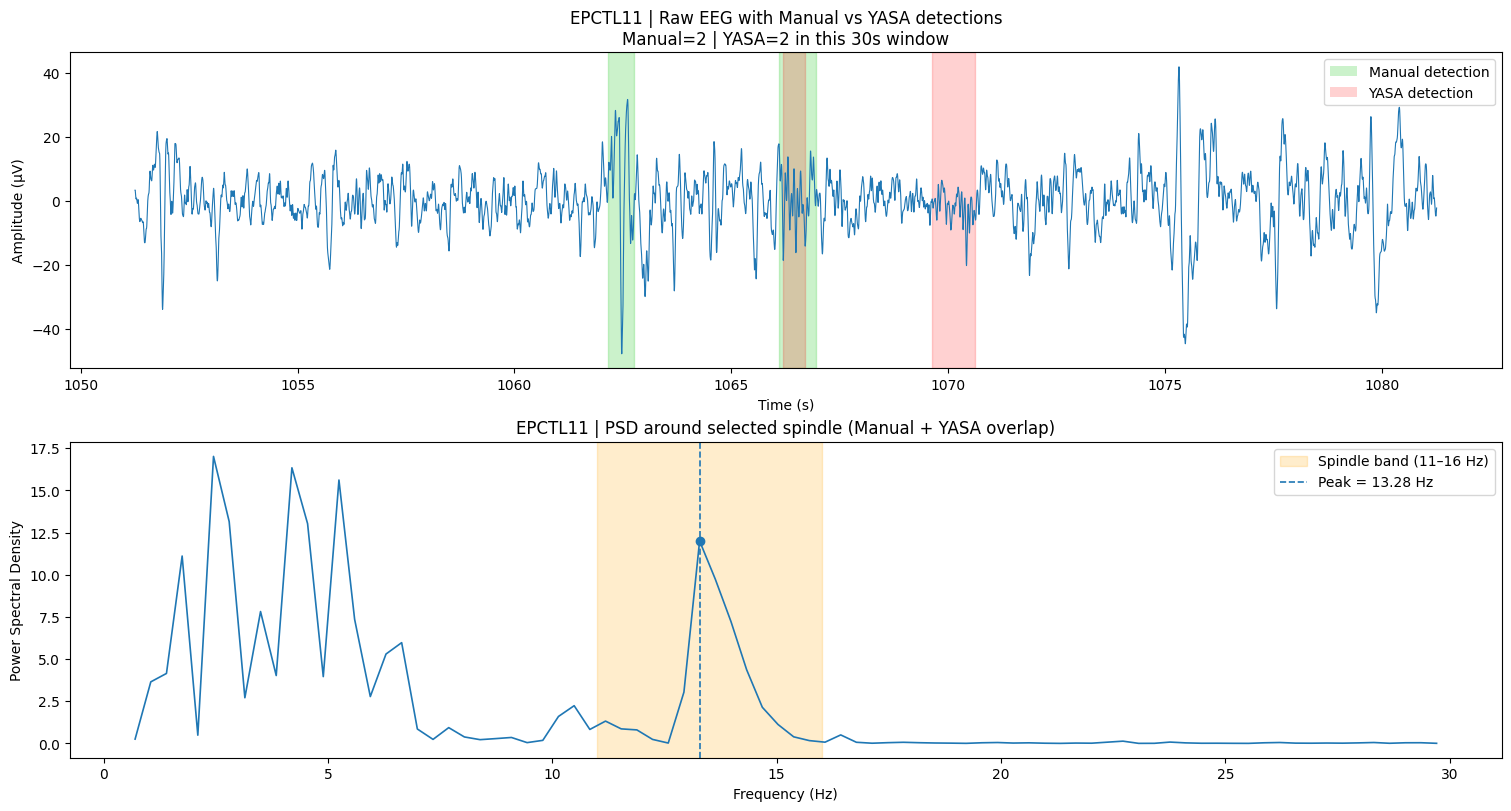

EPCTL12 | window start = 4936.67s | mode = overlap


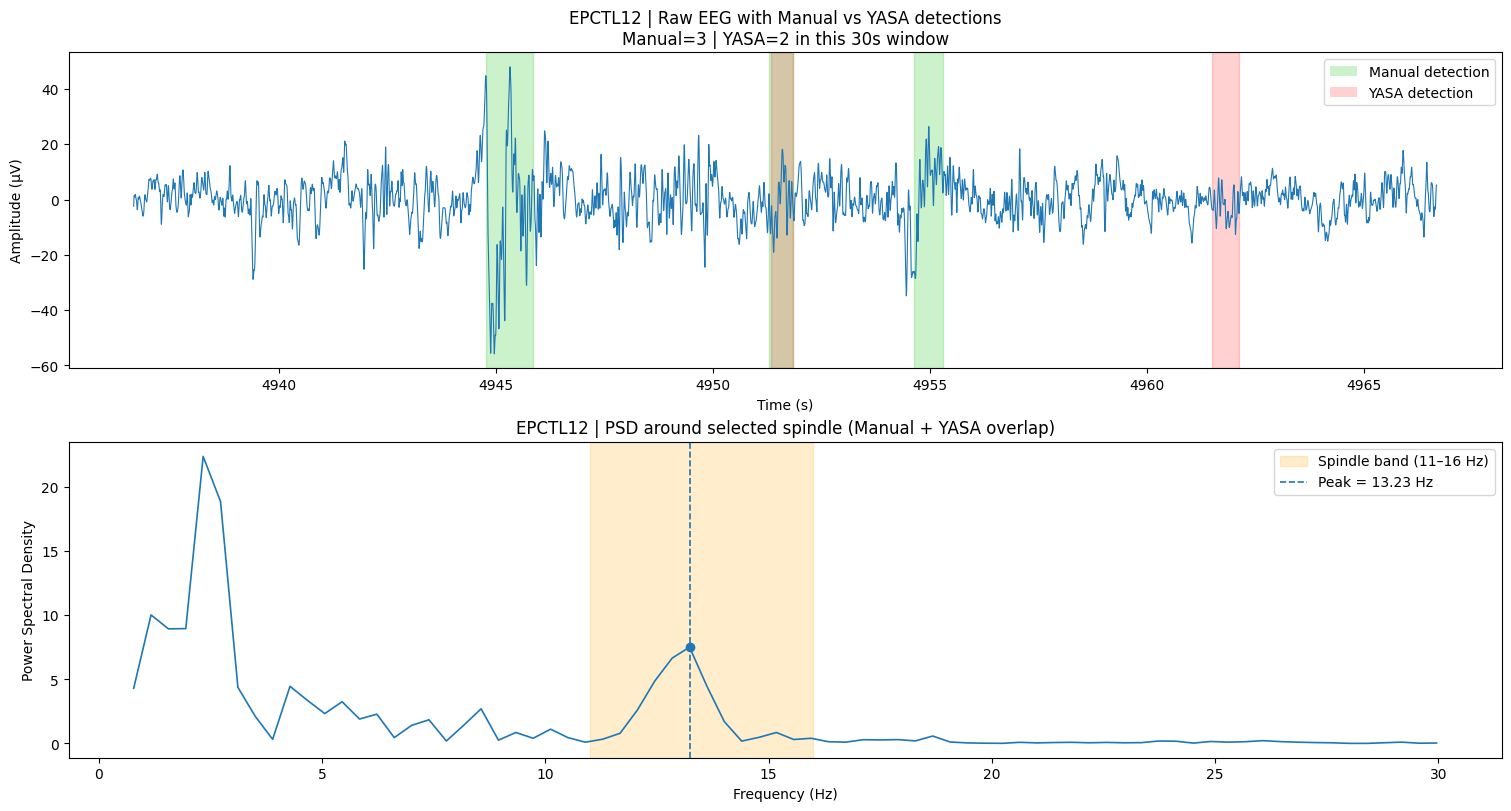

In [59]:
for pid in VISUAL_PIDS:
    start_sec = selected_windows[pid]["start_sec"]
    mode = selected_windows[pid]["selection_mode"]

    print(f"EPCTL{pid} | window start = {start_sec:.2f}s | mode = {mode}")

    plot_visual_proof(
        pid=pid,
        manual_result=visual_manual[pid],
        yasa_events=selected_windows[pid]["yasa_events"],
        start_sec=selected_windows[pid]["start_sec"],
        duration_sec=30,
        pad_sec=1.0,
        save_path=VISUAL_DIR / f"EPCTL{pid}_visual_proof.png"
    )

`Insights`:

The visual proof shows that the manual detector and YASA capture similar spindle-like activity, but the agreement is not exactly the same for every participant.

For **EPCTL11**, the agreement is strong. In this 30-second segment, both methods detect **2 spindle events**, and the overlapping event occurs at nearly the same time. The PSD plot shows a clear peak at **13.28 Hz**, which is well inside the spindle band (**11–16 Hz**). This supports that the detected event is a valid spindle and that the manual detector is closely matching YASA for this participant.

For **EPCTL12**, the manual detector is slightly more sensitive. In this segment, the manual method detects **3 events**, while YASA detects **2 events**. Even though the overlap is not perfect, both methods still identify spindle activity in the same general region. The PSD peak at **13.23 Hz** is also inside the spindle band, which supports the presence of real spindle-related activity.

Overall, these examples show that the manual detector is able to capture the expected spindle frequency pattern and often agrees with YASA, while still showing some subject-level differences in detection sensitivity.

## 8. Summary & Discussion

**Objective Achieved**<br>
Successfully implemented a classical, unsupervised sleep spindle detection pipeline tailored to identical 11–16 Hz sigma-band energy on the central (Cz) lead. By utilizing a band-pass filter, a Hilbert transform for amplitude envelope extraction, and sliding-window threshold logic, we reliably extracted physiological sleep spindle events bounding 0.5–2.0 seconds in stage N2 sleep.

**Parameter Calibration & Validation**<br>
To prevent data leakage, hyperparameter tuning was restricted to a single hold-out calibration subject (EPCTL11). A systematic mathematical grid search identified that a narrow smoothing window of `100 ms` combined with a standard deviation threshold multiplier of `k=1.2` aligned most accurately with the sophisticated YASA baseline (achieving +3.4% parity on the calibration subject).

**Inter-Subject Variability & Generalization Failures**<br>
While the derived static threshold generalized excellently to specific participants (e.g., EPCTL14), applying absolute amplitude thresholds globally across datasets exposed extreme physiological variability. 
*   **Over-Sensitivity:** The absolute threshold was too forgiving for the high-voltage baseline noise in EPCTL15, heavily over-detecting false-positive fragmented signals.
*   **Conservative Constraints:** Conversely, the threshold remained overly strict for EPCTL13, discarding legitimate low-voltage spindles that the YASA baseline captured.

**Conclusion & Future Directions**<br>
The manual implementation serves as a mathematically rigid proof-of-concept for detecting prominent sigma-burst oscillations. However, the out-of-sample generalization issues perfectly highlight the limitations of using a universal, static amplitude threshold for varying human physiologies. The performance discrepancy justifies why robust industrial algorithms (like YASA) utilize dynamic, multi-factorial thresholding—incorporating relative band power, spatial correlation, and moving averages—to automatically normalize morphological differences between patients.